# 08 - Analiza końcowa

In [1]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, APPNP

os.makedirs('../results/analysis', exist_ok=True)

dataset_cora     = Planetoid(root='../data/Cora',     name='Cora')
dataset_citeseer = Planetoid(root='../data/Citeseer', name='Citeseer')
data_cora     = dataset_cora[0]
data_citeseer = dataset_citeseer[0]

CLASS_NAMES_CORA = ['Case_Based','Genetic_Algorithms','Neural_Networks',
    'Probabilistic_Methods','Reinforcement_Learning','Rule_Learning','Theory']
CLASS_NAMES_CITESEER = ['Agents','AI','DB','IR','ML','HCI']

## wczytanie wyników

In [2]:
with open('../models/all_results.json') as f:
    cora_results = {name: {float(k): v for k, v in res.items()}
                    for name, res in json.load(f).items()}

with open('../models/citeseer_results.json') as f:
    citeseer_results = {name: {float(k): v for k, v in res.items()}
                        for name, res in json.load(f).items()}

with open('../models/noise_results.json') as f:
    noise_results = {name: {float(k): v for k, v in res.items()}
                     for name, res in json.load(f).items()}

ratios     = [0.05, 0.10, 0.20]
labels     = ['5%', '10%', '20%']
seeds      = [42, 123, 456, 789, 1000]
gnn_models = ['GCN', 'GAT', 'GraphSAGE', 'APPNP']

print('Wyniki wczytane')
print(f'Cora:     {list(cora_results.keys())}')
print(f'Citeseer: {list(citeseer_results.keys())}')

Wyniki wczytane
Cora:     ['GCN', 'GAT', 'GraphSAGE', 'APPNP', 'MLP']
Citeseer: ['GCN', 'GAT', 'GraphSAGE', 'APPNP']


## Architwktury i funkcje pomocnicze

In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hid_ch)
        self.conv2 = GCNConv(hid_ch, out_ch)
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=0.5, training=self.training)
        return F.log_softmax(self.conv2(x, ei), dim=1)

class GAT(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_ch, hid_ch, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hid_ch * heads, out_ch, heads=1, dropout=0.6)
    def forward(self, x, ei):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, ei))
        x = F.dropout(x, p=0.6, training=self.training)
        return F.log_softmax(self.conv2(x, ei), dim=1)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hid_ch)
        self.conv2 = SAGEConv(hid_ch, out_ch)
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=0.5, training=self.training)
        return F.log_softmax(self.conv2(x, ei), dim=1)

class APPNPNet(torch.nn.Module):
    def __init__(self, in_ch, hid_ch, out_ch, K=10, alpha=0.1, dropout=0.5):
        super().__init__()
        self.fc1  = torch.nn.Linear(in_ch, hid_ch)
        self.fc2  = torch.nn.Linear(hid_ch, out_ch)
        self.prop = APPNP(K=K, alpha=alpha)
        self.dropout = dropout
    def forward(self, x, ei):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.prop(self.fc2(x), ei), dim=1)

def get_model(name, dataset):
    cfg = {'in_ch': dataset.num_features, 'hid_ch': 64, 'out_ch': dataset.num_classes}
    if name == 'GCN':       return GCN(**cfg)
    if name == 'GAT':       return GAT(**{**cfg, 'hid_ch': 8})
    if name == 'GraphSAGE': return GraphSAGE(**cfg)
    if name == 'APPNP':     return APPNPNet(**cfg)

def get_optimizer(name, model):
    if name == 'GAT': return torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    return torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    available = (~data.test_mask).nonzero(as_tuple=True)[0]
    train_size = int(data.num_nodes * label_ratio)
    shuffled = available[torch.randperm(len(available))]
    mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    mask[shuffled[:train_size]] = True
    return mask

def train_model(model, optimizer, data):
    for _ in range(200):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        F.nll_loss(out[data.train_mask], data.y[data.train_mask]).backward()
        optimizer.step()

def get_predictions(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    return out.argmax(dim=1), out

# 1 - Zbiorcze porównanie modeli

In [4]:
print('=== CORA ===')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name in gnn_models + ['MLP']:
    if name not in cora_results: continue
    row = f'{name:<12}'
    for ratio in ratios:
        accs = cora_results[name][ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)

print('\n=== CITESEER ===')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name in gnn_models:
    if name not in citeseer_results: continue
    row = f'{name:<12}'
    for ratio in ratios:
        accs = citeseer_results[name][ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)

=== CORA ===
Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156
APPNP         0.8216±0.0101  0.8392±0.0126  0.8550±0.0113
MLP           0.5722±0.0221  0.6266±0.0134  0.6958±0.0135

=== CITESEER ===
Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.6746±0.0206  0.6900±0.0177  0.6926±0.0140
GAT           0.6900±0.0165  0.7106±0.0114  0.7292±0.0109
GraphSAGE     0.7012±0.0067  0.7182±0.0140  0.7352±0.0055
APPNP         0.6902±0.0154  0.7056±0.0115  0.7202±0.0157


## 1.1 - wykres zbiorczy Cora + Citeseer

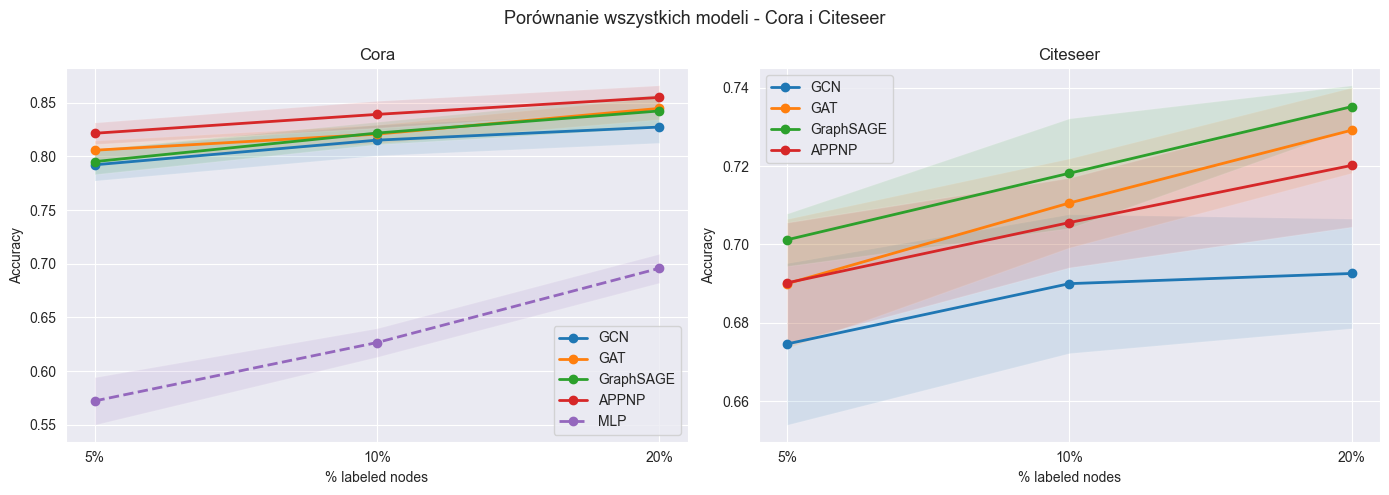

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ds_name, results, model_list) in zip(axes, [
    ('Cora',     cora_results,     gnn_models + ['MLP']),
    ('Citeseer', citeseer_results, gnn_models),
]):
    for name in model_list:
        if name not in results: continue
        means = [np.mean(results[name][r]) for r in ratios]
        stds  = [np.std(results[name][r])  for r in ratios]
        style = '--' if name == 'MLP' else '-'
        ax.plot(labels, means, marker='o',
                linestyle=style, linewidth=2, label=name)
        ax.fill_between(labels,
                        [m-s for m,s in zip(means,stds)],
                        [m+s for m,s in zip(means,stds)],
                        alpha=0.12)
    ax.set_title(ds_name)
    ax.set_xlabel('% labeled nodes')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.suptitle('Porównanie wszystkich modeli - Cora i Citeseer', fontsize=13)
plt.tight_layout()
plt.savefig('../results/analysis/full_comparison.png')
plt.show()

## 1.2 - stabilność (odchylenie standardowe)

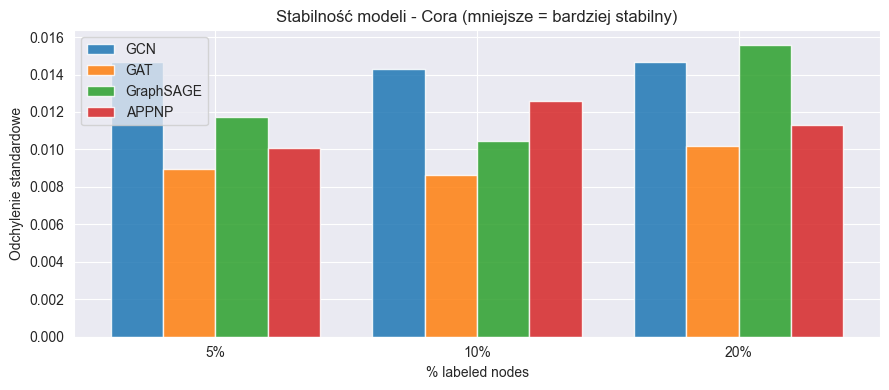

In [6]:
plt.figure(figsize=(9, 4))
x = np.arange(len(labels))
width = 0.2

for i, name in enumerate(gnn_models):
    stds = [np.std(cora_results[name][r]) for r in ratios]
    plt.bar(x + i*width, stds, width, label=name, alpha=0.85)

plt.xlabel('% labeled nodes')
plt.ylabel('Odchylenie standardowe')
plt.title('Stabilność modeli - Cora (mniejsze = bardziej stabilny)')
plt.xticks(x + width*1.5, labels)
plt.legend()
plt.tight_layout()
plt.savefig('../results/analysis/stability.png')
plt.show()

# 2 - Per-class accuracy

In [7]:
data = data_cora
original_train_mask = data.train_mask.clone()
per_class_results = {}

for model_name in gnn_models:
    per_class_results[model_name] = {}
    for ratio in ratios:
        data.train_mask = create_split(data, ratio, seed=42)
        model = get_model(model_name, dataset_cora)
        optimizer = get_optimizer(model_name, model)
        train_model(model, optimizer, data)
        pred, _ = get_predictions(model, data)

        y_true = data.y[data.test_mask].numpy()
        y_pred = pred[data.test_mask].numpy()

        per_class_acc = {}
        for cls in range(dataset_cora.num_classes):
            mask = y_true == cls
            if mask.sum() > 0:
                per_class_acc[cls] = (y_pred[mask] == y_true[mask]).mean()
        per_class_results[model_name][ratio] = per_class_acc
        print(f'{model_name} {ratio:.0%}')

data.train_mask = original_train_mask

GCN 5%
GCN 10%
GCN 20%
GAT 5%
GAT 10%
GAT 20%
GraphSAGE 5%
GraphSAGE 10%
GraphSAGE 20%
APPNP 5%
APPNP 10%
APPNP 20%


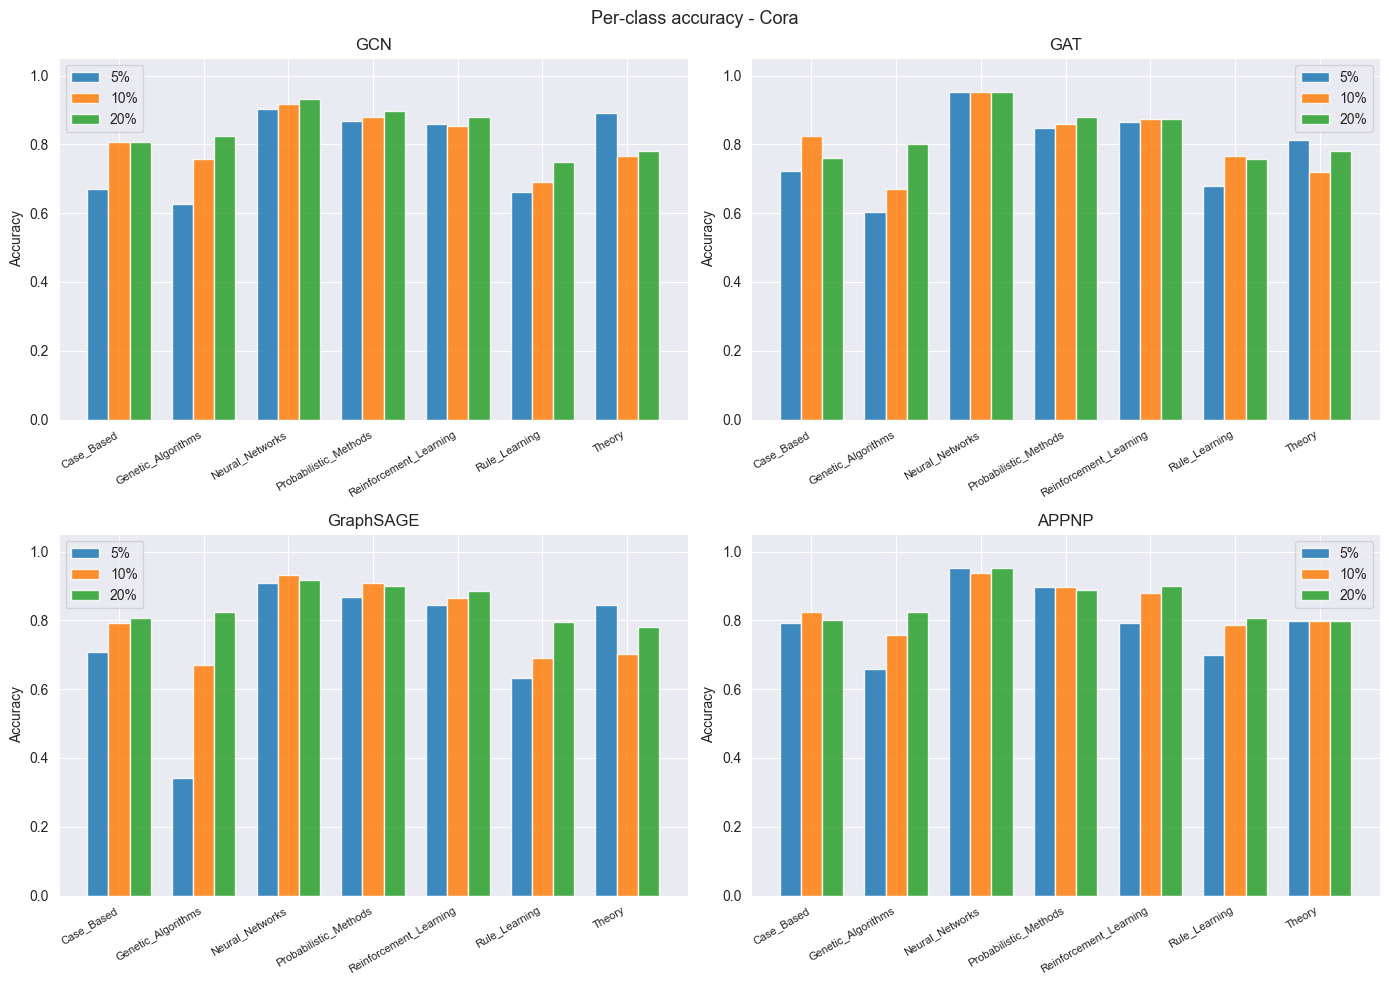

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(gnn_models):
    ax = axes[idx]
    x = np.arange(dataset_cora.num_classes)
    width = 0.25
    for i, (ratio, label) in enumerate(zip(ratios, labels)):
        accs = [per_class_results[model_name][ratio].get(c, 0)
                for c in range(dataset_cora.num_classes)]
        ax.bar(x + i*width, accs, width, label=label, alpha=0.85)
    ax.set_title(model_name)
    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES_CORA, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.suptitle('Per-class accuracy - Cora', fontsize=13)
plt.tight_layout()
plt.savefig('../results/analysis/per_class_accuracy.png')
plt.show()

In [9]:
print('=== Per-class accuracy — Cora ===\n')

for model_name in gnn_models:
    print(f'--- {model_name} ---')
    print(f'{"Klasa":<25} {"5%":>8} {"10%":>8} {"20%":>8} {"Przyrost":>10}')
    print('-' * 55)
    for cls in range(dataset_cora.num_classes):
        acc_5  = per_class_results[model_name][0.05].get(cls, 0)
        acc_10 = per_class_results[model_name][0.10].get(cls, 0)
        acc_20 = per_class_results[model_name][0.20].get(cls, 0)
        przyrost = acc_20 - acc_5
        print(f'{CLASS_NAMES_CORA[cls]:<25} {acc_5:>8.4f} {acc_10:>8.4f} {acc_20:>8.4f} {przyrost:>+10.4f}')
    print()

=== Per-class accuracy — Cora ===

--- GCN ---
Klasa                           5%      10%      20%   Przyrost
-------------------------------------------------------
Case_Based                  0.6692   0.8077   0.8077    +0.1385
Genetic_Algorithms          0.6264   0.7582   0.8242    +0.1978
Neural_Networks             0.9028   0.9167   0.9306    +0.0278
Probabilistic_Methods       0.8683   0.8809   0.8966    +0.0282
Reinforcement_Learning      0.8591   0.8523   0.8792    +0.0201
Rule_Learning               0.6602   0.6893   0.7476    +0.0874
Theory                      0.8906   0.7656   0.7812    -0.1094

--- GAT ---
Klasa                           5%      10%      20%   Przyrost
-------------------------------------------------------
Case_Based                  0.7231   0.8231   0.7615    +0.0385
Genetic_Algorithms          0.6044   0.6703   0.8022    +0.1978
Neural_Networks             0.9514   0.9514   0.9514    +0.0000
Probabilistic_Methods       0.8464   0.8589   0.8809    +0.0

In [10]:
print('Przyrost accuracy (20% vs 5% etykiet) - uśredniony po modelach:')
print('-' * 45)
gains = {}
for cls in range(dataset_cora.num_classes):
    model_gains = []
    for model_name in gnn_models:
        acc_5  = per_class_results[model_name][0.05].get(cls, 0)
        acc_20 = per_class_results[model_name][0.20].get(cls, 0)
        model_gains.append(acc_20 - acc_5)
    gains[cls] = np.mean(model_gains)
    print(f'  {CLASS_NAMES_CORA[cls]:<25}: {gains[cls]:+.4f}')

best_cls  = max(gains, key=gains.get)
worst_cls = min(gains, key=gains.get)
print(f'\nNajwiększy przyrost:  {CLASS_NAMES_CORA[best_cls]} ({gains[best_cls]:+.4f})')
print(f'Najmniejszy przyrost: {CLASS_NAMES_CORA[worst_cls]} ({gains[worst_cls]:+.4f})')

Przyrost accuracy (20% vs 5% etykiet) - uśredniony po modelach:
---------------------------------------------
  Case_Based               : +0.0712
  Genetic_Algorithms       : +0.2610
  Neural_Networks          : +0.0087
  Probabilistic_Methods    : +0.0212
  Reinforcement_Learning   : +0.0436
  Rule_Learning            : +0.1092
  Theory                   : -0.0508

Największy przyrost:  Genetic_Algorithms (+0.2610)
Najmniejszy przyrost: Theory (-0.0508)


# 3 - Confusion matrix
Wszzystkie 4 modele przy 5% etykiet

GCN: done
GAT: done
GraphSAGE: done
APPNP: done


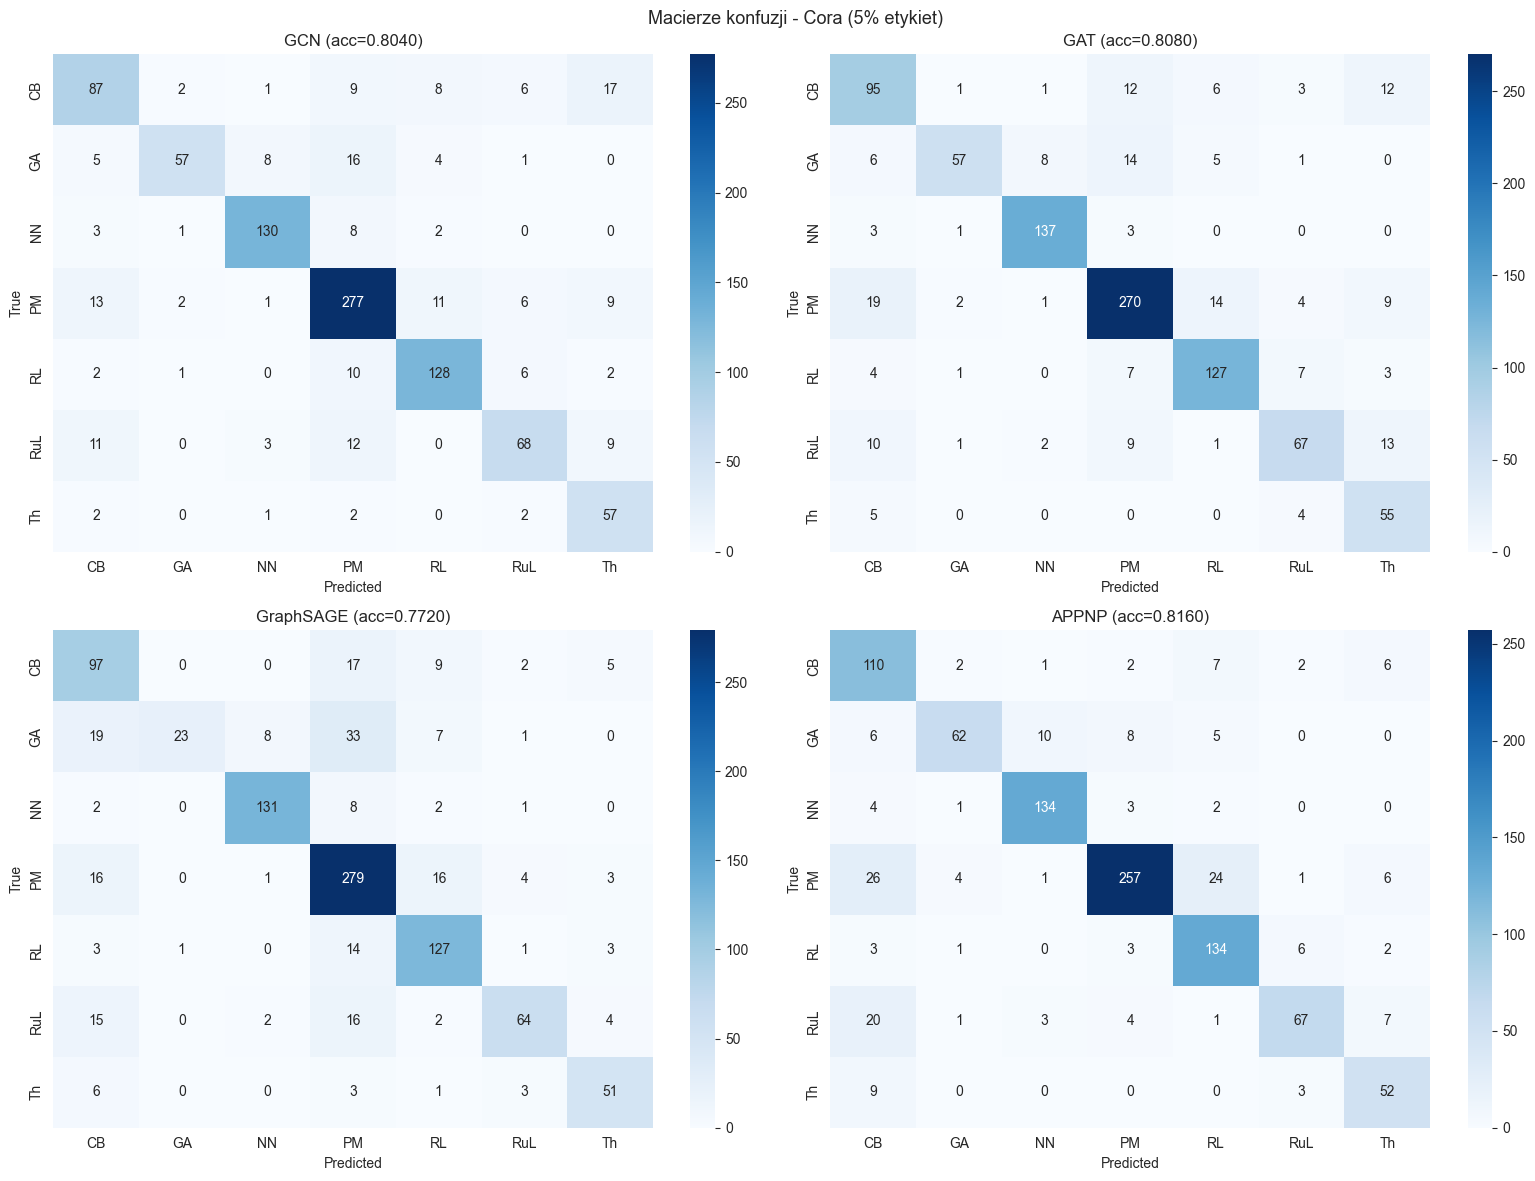

CB=Case_Based, GA=Genetic_Alg, NN=Neural_Net, PM=Probabilistic, RL=Reinforcement, RuL=Rule, Th=Theory


In [11]:
data = data_cora
data.train_mask = create_split(data, 0.05, seed=42)
conf_matrices = {}

for model_name in gnn_models:
    model = get_model(model_name, dataset_cora)
    optimizer = get_optimizer(model_name, model)
    train_model(model, optimizer, data)
    pred, _ = get_predictions(model, data)
    y_true = data.y[data.test_mask].numpy()
    y_pred = pred[data.test_mask].numpy()
    conf_matrices[model_name] = confusion_matrix(y_true, y_pred)
    print(f'{model_name}: done')

data.train_mask = original_train_mask

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
short_names = ['CB','GA','NN','PM','RL','RuL','Th']

for idx, model_name in enumerate(gnn_models):
    ax = axes[idx]
    sns.heatmap(conf_matrices[model_name], annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names, ax=ax)
    acc = np.diag(conf_matrices[model_name]).sum() / conf_matrices[model_name].sum()
    ax.set_title(f'{model_name} (acc={acc:.4f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Macierze konfuzji - Cora (5% etykiet)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/analysis/confusion_matrices.png')
plt.show()
print('CB=Case_Based, GA=Genetic_Alg, NN=Neural_Net, PM=Probabilistic, RL=Reinforcement, RuL=Rule, Th=Theory')

In [12]:
from sklearn.metrics import classification_report

for model_name in gnn_models:
    data.train_mask = create_split(data_cora, 0.05, seed=42)
    y_true = data_cora.y[data_cora.test_mask].numpy()
    
    cm = conf_matrices[model_name]
    
    print(f'\n=== {model_name} (5% etykiet) ===')
    
    # ogólna accuracy
    acc = np.diag(cm).sum() / cm.sum()
    print(f'Overall accuracy: {acc:.4f}')
    
    # per-class precision, recall, f1
    model = get_model(model_name, dataset_cora)
    optimizer = get_optimizer(model_name, model)
    train_model(model, optimizer, data_cora)
    pred, _ = get_predictions(model, data_cora)
    y_pred = pred[data_cora.test_mask].numpy()
    
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES_CORA,
        digits=4
    ))
    
    # największe pomyłki
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)
    top_errors = []
    for i in range(len(CLASS_NAMES_CORA)):
        for j in range(len(CLASS_NAMES_CORA)):
            if cm_copy[i, j] > 0:
                top_errors.append((cm_copy[i, j], CLASS_NAMES_CORA[i], CLASS_NAMES_CORA[j]))
    top_errors.sort(reverse=True)
    
    print('Top 3 największe pomyłki:')
    for count, true_cls, pred_cls in top_errors[:3]:
        print(f'  {true_cls} → {pred_cls}: {count} przypadków')
    print('-' * 60)


=== GCN (5% etykiet) ===
Overall accuracy: 0.8040
                        precision    recall  f1-score   support

            Case_Based     0.7073    0.6692    0.6877       130
    Genetic_Algorithms     0.9048    0.6264    0.7403        91
       Neural_Networks     0.9028    0.9028    0.9028       144
 Probabilistic_Methods     0.8293    0.8683    0.8484       319
Reinforcement_Learning     0.8366    0.8591    0.8477       149
         Rule_Learning     0.7640    0.6602    0.7083       103
                Theory     0.6064    0.8906    0.7215        64

              accuracy                         0.8040      1000
             macro avg     0.7930    0.7824    0.7795      1000
          weighted avg     0.8110    0.8040    0.8028      1000

Top 3 największe pomyłki:
  Case_Based → Theory: 17 przypadków
  Genetic_Algorithms → Probabilistic_Methods: 16 przypadków
  Probabilistic_Methods → Case_Based: 13 przypadków
------------------------------------------------------------

=== G

# 4 - t-SNE embeddings

In [13]:
data = data_cora
data.train_mask = create_split(data, 0.05, seed=42)
embeddings = {}

for model_name in gnn_models:
    model = get_model(model_name, dataset_cora)
    optimizer = get_optimizer(model_name, model)
    train_model(model, optimizer, data)
    model.eval()
    with torch.no_grad():
        if model_name in ['GCN', 'GraphSAGE']:
            emb = F.relu(model.conv1(data.x, data.edge_index))
        elif model_name == 'GAT':
            emb = F.elu(model.conv1(data.x, data.edge_index))
        elif model_name == 'APPNP':
            emb = F.relu(model.fc1(data.x))
    embeddings[model_name] = emb.numpy()
    print(f'{model_name}: shape={emb.shape}')

data.train_mask = original_train_mask

GCN: shape=torch.Size([2708, 64])
GAT: shape=torch.Size([2708, 64])
GraphSAGE: shape=torch.Size([2708, 64])
APPNP: shape=torch.Size([2708, 64])


t-SNE dla GCN...
t-SNE dla GAT...
t-SNE dla GraphSAGE...
t-SNE dla APPNP...


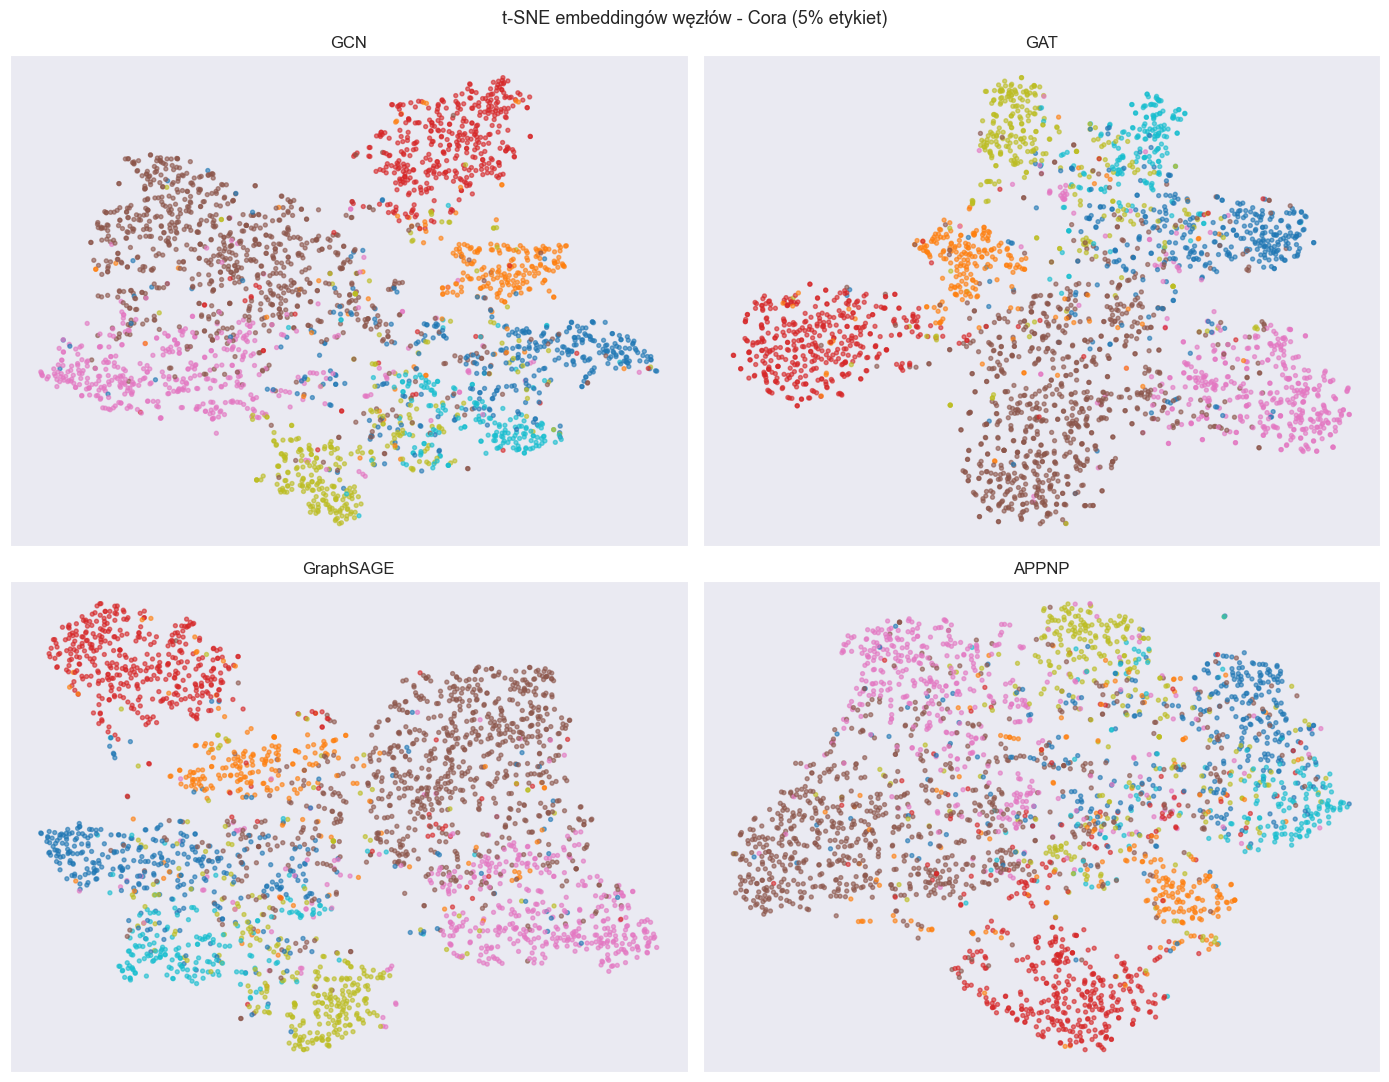

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, model_name in enumerate(gnn_models):
    print(f't-SNE dla {model_name}...')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    emb_2d = tsne.fit_transform(embeddings[model_name])
    ax = axes[idx]
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
               c=data_cora.y.numpy(), cmap='tab10', alpha=0.6, s=8)
    ax.set_title(model_name)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE embeddingów węzłów - Cora (5% etykiet)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/analysis/tsne_all_models.png')
plt.show()

## 4.1 - Analiza attention weights (GAT)
Które połączenia GAT uznaje za najważniejsze?

In [15]:
data = data_cora
data.train_mask = create_split(data, 0.05, seed=42)

# trenowanie GAT z return_attention_weights
gat_model = get_model('GAT', dataset_cora)
optimizer = get_optimizer('GAT', gat_model)
train_model(gat_model, optimizer, data)

gat_model.eval()
with torch.no_grad():
    x = F.dropout(data.x, p=0.0)  # bez dropout przy ewaluacji
    # pobieranie attention weights z pierwszej warstwy
    _, (edge_index_att, alpha) = gat_model.conv1(
        x, data.edge_index, return_attention_weights=True
    )

# alpha - [num_edges, num_heads]
alpha_mean = alpha.mean(dim=1).detach().numpy()

print(f'Krawędzie: {edge_index_att.shape[1]}')
print(f'Alpha shape: {alpha.shape}  (krawędzie × głowice)')
print(f'Min alpha: {alpha_mean.min():.4f}')
print(f'Max alpha: {alpha_mean.max():.4f}')
print(f'Mean alpha: {alpha_mean.mean():.4f}')

data.train_mask = original_train_mask

Krawędzie: 13264
Alpha shape: torch.Size([13264, 8])  (krawędzie × głowice)
Min alpha: 0.0043
Max alpha: 0.6223
Mean alpha: 0.2042


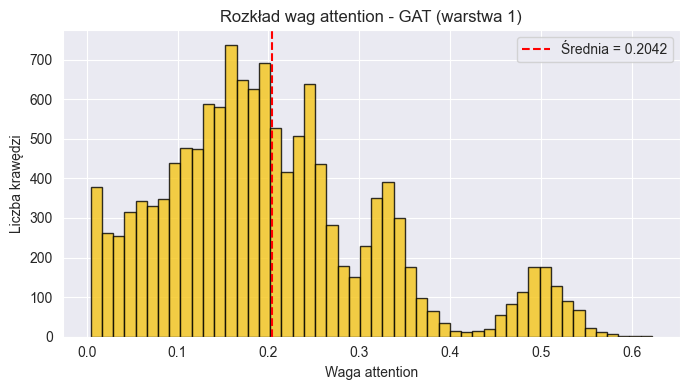

In [16]:
plt.figure(figsize=(7, 4))

plt.hist(alpha_mean, bins=50, color='#F5C518', edgecolor='black', alpha=0.8)
plt.xlabel('Waga attention')
plt.ylabel('Liczba krawędzi')
plt.title('Rozkład wag attention - GAT (warstwa 1)')
plt.axvline(alpha_mean.mean(), color='red', linestyle='--',
            label=f'Średnia = {alpha_mean.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('../results/analysis/attention_weights.png')
plt.show()

Histogram wag attention ujawnia bimodalny rozkład - GAT wykształcił binarną strategię ważenia sąsiadów. Krawędzie skupiają się wokół dwóch wartości: ok. 0.15 dla cytowań mało informatywnych i ok. 0.5 dla cytowań kluczowych. Sugeruje to że model nauczył się skutecznie odróżniać istotne połączenia od szumu w grafie cytowań.

In [17]:
# Top 10 najważniejszych połączeń
top_k = 10
top_indices = np.argsort(alpha_mean)[-top_k:][::-1]

print(f'Top {top_k} krawędzi z najwyższą wagą attention:')
print(f'{"#":<4} {"Źródło":>8} {"Cel":>8} {"Waga":>8} {"Klasa src":>12} {"Klasa dst":>12}')
print('-' * 55)
for rank, idx in enumerate(top_indices):
    src = edge_index_att[0, idx].item()
    dst = edge_index_att[1, idx].item()
    weight = alpha_mean[idx]
    cls_src = CLASS_NAMES_CORA[data_cora.y[src].item()][:10]
    cls_dst = CLASS_NAMES_CORA[data_cora.y[dst].item()][:10]
    print(f'{rank+1:<4} {src:>8} {dst:>8} {weight:>8.4f} {cls_src:>12} {cls_dst:>12}')

# czy wysokie wagi łączą węzły tej samej klasy?
same_class = sum(
    data_cora.y[edge_index_att[0, idx]].item() == data_cora.y[edge_index_att[1, idx]].item()
    for idx in top_indices
)
print(f'\nSpośród top {top_k}: {same_class}/{top_k} łączy węzły tej samej klasy')

Top 10 krawędzi z najwyższą wagą attention:
#      Źródło      Cel     Waga    Klasa src    Klasa dst
-------------------------------------------------------
1        1642     2658   0.6223   Neural_Net   Neural_Net
2        1765      825   0.6047   Neural_Net   Neural_Net
3        1642     2657   0.6004   Neural_Net   Neural_Net
4         954      677   0.5976   Reinforcem   Reinforcem
5        2421     2421   0.5951   Neural_Net   Neural_Net
6        1612     1612   0.5836   Neural_Net   Neural_Net
7        1861     1861   0.5832   Probabilis   Probabilis
8         442     2362   0.5831   Reinforcem   Reinforcem
9         954     1112   0.5830   Reinforcem   Reinforcem
10       1358       34   0.5814   Neural_Net   Neural_Net

Spośród top 10: 10/10 łączy węzły tej samej klasy


# 5 - odporność na szum

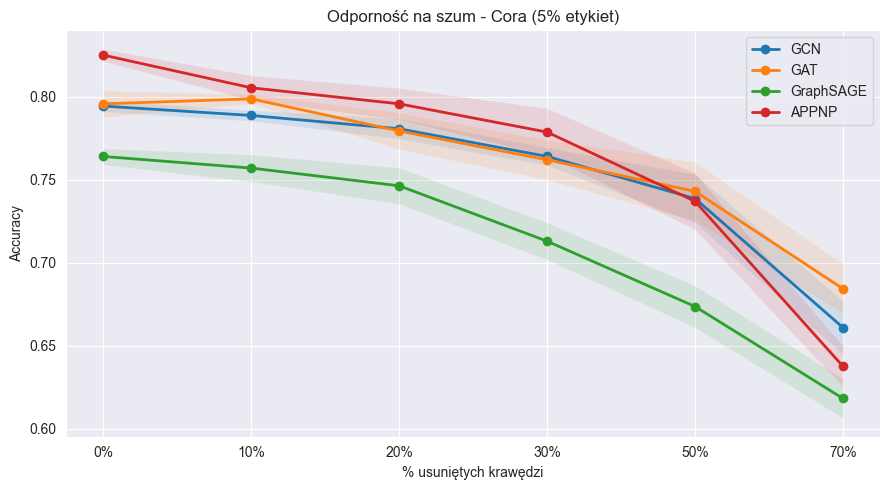


Spadek accuracy przy 50% usuniętych krawędzi:
  GCN         : 0.7943 -> 0.7387 (-0.0557)
  GAT         : 0.7957 -> 0.7430 (-0.0527)
  GraphSAGE   : 0.7640 -> 0.6737 (-0.0903)
  APPNP       : 0.8250 -> 0.7370 (-0.0880)


In [18]:
drop_ratios = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]
drop_labels = [f'{int(r*100)}%' for r in drop_ratios]

plt.figure(figsize=(9, 5))
for name in gnn_models:
    if name not in noise_results: continue
    means = [np.mean(noise_results[name][dr]) for dr in drop_ratios]
    stds  = [np.std(noise_results[name][dr])  for dr in drop_ratios]
    plt.plot(drop_labels, means, marker='o', linewidth=2, label=name)
    plt.fill_between(drop_labels,
                     [m-s for m,s in zip(means,stds)],
                     [m+s for m,s in zip(means,stds)],
                     alpha=0.12)

plt.xlabel('% usuniętych krawędzi')
plt.ylabel('Accuracy')
plt.title('Odporność na szum - Cora (5% etykiet)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/analysis/edge_noise_summary.png')
plt.show()

print('\nSpadek accuracy przy 50% usuniętych krawędzi:')
for name in gnn_models:
    if name not in noise_results: continue
    base = np.mean(noise_results[name][0.0])
    at50 = np.mean(noise_results[name][0.5])
    print(f'  {name:<12}: {base:.4f} -> {at50:.4f} ({at50-base:+.4f})')

# 6 - wnioski końcowe

In [19]:
print('\n1. RANKING MODELI (Cora, 5% etykiet):')
ranking = sorted(gnn_models, key=lambda n: np.mean(cora_results[n][0.05]), reverse=True)
for i, name in enumerate(ranking):
    acc = np.mean(cora_results[name][0.05])
    std = np.std(cora_results[name][0.05])
    print(f'  {i+1}. {name:<12}: {acc:.4f} +/- {std:.4f}')

print('\n2. WARTOŚĆ STRUKTURY GRAFU (przewaga nad MLP):')
if 'MLP' in cora_results:
    for name in gnn_models:
        d5  = np.mean(cora_results[name][0.05]) - np.mean(cora_results['MLP'][0.05])
        d20 = np.mean(cora_results[name][0.20]) - np.mean(cora_results['MLP'][0.20])
        print(f'  {name:<12}: +{d5:.4f} przy 5%,  +{d20:.4f} przy 20%')

print('\n3. SPÓJNOŚĆ RANKINGU - CZY WNIOSKI SĄ OGÓLNE?')
print('  Cora:    ', ' > '.join(sorted(gnn_models, key=lambda n: np.mean(cora_results[n][0.05]), reverse=True)))
if citeseer_results:
    cs_models = [n for n in gnn_models if n in citeseer_results]
    print('  Citeseer:', ' > '.join(sorted(cs_models, key=lambda n: np.mean(citeseer_results[n][0.05]), reverse=True)))

print('\n4. STABILNOŚĆ - najmniejsze std przy 5% etykiet:')
most_stable = min(gnn_models, key=lambda n: np.std(cora_results[n][0.05]))
print(f'  {most_stable} (std={np.std(cora_results[most_stable][0.05]):.4f})')

print('\n5. ODPORNOŚĆ NA SZUM - spadek przy 50% usuniętych krawędzi:')
if noise_results:
    drops = {n: np.mean(noise_results[n][0.5]) - np.mean(noise_results[n][0.0])
             for n in gnn_models if n in noise_results}
    most_robust = max(drops, key=drops.get)
    print(f'  Najbardziej odporny: {most_robust} (spadek={drops[most_robust]:+.4f})')
    for name, d in sorted(drops.items(), key=lambda x: x[1], reverse=True):
        print(f'  {name:<12}: {d:+.4f}')


1. RANKING MODELI (Cora, 5% etykiet):
  1. APPNP       : 0.8216 +/- 0.0101
  2. GAT         : 0.8058 +/- 0.0090
  3. GraphSAGE   : 0.7952 +/- 0.0118
  4. GCN         : 0.7922 +/- 0.0147

2. WARTOŚĆ STRUKTURY GRAFU (przewaga nad MLP):
  GCN         : +0.2200 przy 5%,  +0.1316 przy 20%
  GAT         : +0.2336 przy 5%,  +0.1490 przy 20%
  GraphSAGE   : +0.2230 przy 5%,  +0.1466 przy 20%
  APPNP       : +0.2494 przy 5%,  +0.1592 przy 20%

3. SPÓJNOŚĆ RANKINGU - CZY WNIOSKI SĄ OGÓLNE?
  Cora:     APPNP > GAT > GraphSAGE > GCN
  Citeseer: GraphSAGE > APPNP > GAT > GCN

4. STABILNOŚĆ - najmniejsze std przy 5% etykiet:
  GAT (std=0.0090)

5. ODPORNOŚĆ NA SZUM - spadek przy 50% usuniętych krawędzi:
  Najbardziej odporny: GAT (spadek=-0.0527)
  GAT         : -0.0527
  GCN         : -0.0557
  APPNP       : -0.0880
  GraphSAGE   : -0.0903


## Zapis

In [20]:
print('Pliki w ../results/analysis/:')
for f in sorted(os.listdir('../results/analysis')):
    size = os.path.getsize(f'../results/analysis/{f}')
    print(f'  {f:<40} {size/1024:.1f} KB')

Pliki w ../results/analysis/:
  attention_weights.png                    25.2 KB
  confusion_matrices.png                   98.9 KB
  edge_noise_summary.png                   79.4 KB
  full_comparison.png                      92.9 KB
  per_class_accuracy.png                   72.0 KB
  stability.png                            29.8 KB
  tsne_all_models.png                      782.0 KB
